# lab 2: autoencoder și autoencoder variațional pe mnist

scopul lucrării: să construim două modele de tip encoder și decoder, un autoencoder clasic (ae) și un autoencoder variațional (vae). le antrenăm pe mnist și comparăm cum comprimă, reconstruiesc și generează imagini.

encoderul micșorează imaginea într-un cod scurt. decoderul face din acest cod imaginea la loc.

ambele modele au aceleași straturi: 784, apoi 128, apoi 32, apoi 128 și din nou 784. diferența este doar în felul în care se obține codul de 32 de numere și în funcția de pierdere.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.decomposition import PCA

tf.random.set_seed(42)
np.random.seed(42)

## 1. datele

mnist are 60 000 de imagini pentru antrenare și 10 000 pentru test. fiecare imagine are 28 pe 28 pixeli, cu nuanțe de gri de la 0 la 255.

împărțim pixelii la 255, ca să fie între 0 și 1. apoi facem din fiecare imagine un vector de 784 de valori.

etichetele cifrelor nu sunt folosite la antrenare. le folosim doar ca să colorăm graficele.

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32").reshape(-1, 784) / 255.0
x_test = x_test.astype("float32").reshape(-1, 784) / 255.0

print(x_train.shape, x_test.shape)

(60000, 784) (10000, 784)


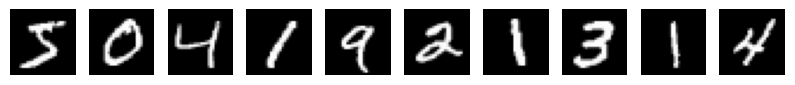

In [5]:
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()

## 2. autoencoderul clasic

encoderul transformă imaginea într-un cod fix de 32 de numere. decoderul transformă codul înapoi în imagine.

modelul învață să dea la ieșire aceeași imagine pe care a primit-o. pierderea este binary cross entropy între imaginea de intrare și cea de ieșire.

In [6]:
LATENT = 32
EPOCHS = 20
BATCH = 256

ae_encoder = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(LATENT),
], name="ae_encoder")

ae_decoder = keras.Sequential([
    layers.Input(shape=(LATENT,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid"),
], name="ae_decoder")

inp = layers.Input(shape=(784,))
autoencoder = keras.Model(inp, ae_decoder(ae_encoder(inp)), name="autoencoder")
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_encoder (Sequential)         │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ae_decoder (Sequential)         │ (None, 784)            │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

ae_history = autoencoder.fit(
    x_train, x_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(x_test, x_test),
    verbose=2,
)

Epoch 1/20
235/235 - 2s - 10ms/step - loss: 0.2202 - val_loss: 0.1431
Epoch 2/20
235/235 - 1s - 6ms/step - loss: 0.1272 - val_loss: 0.1135
Epoch 3/20
235/235 - 1s - 6ms/step - loss: 0.1089 - val_loss: 0.1028
Epoch 4/20
235/235 - 1s - 5ms/step - loss: 0.1018 - val_loss: 0.0987
Epoch 5/20
235/235 - 1s - 6ms/step - loss: 0.0981 - val_loss: 0.0958
Epoch 6/20
235/235 - 1s - 5ms/step - loss: 0.0954 - val_loss: 0.0935
Epoch 7/20
235/235 - 1s - 5ms/step - loss: 0.0934 - val_loss: 0.0917
Epoch 8/20
235/235 - 1s - 5ms/step - loss: 0.0918 - val_loss: 0.0902
Epoch 9/20
235/235 - 1s - 5ms/step - loss: 0.0906 - val_loss: 0.0891
Epoch 10/20
235/235 - 2s - 7ms/step - loss: 0.0896 - val_loss: 0.0882
Epoch 11/20
235/235 - 2s - 8ms/step - loss: 0.0887 - val_loss: 0.0875
Epoch 12/20
235/235 - 2s - 7ms/step - loss: 0.0880 - val_loss: 0.0869
Epoch 13/20
235/235 - 2s - 7ms/step - loss: 0.0875 - val_loss: 0.0864
Epoch 14/20
235/235 - 2s - 7ms/step - loss: 0.0870 - val_loss: 0.0860
Epoch 15/20
235/235 - 2s - 8

## 3. autoencoderul variațional

aici encoderul nu dă un singur cod. el dă doi vectori: media z_mean și logaritmul varianței z_log_var. din ei alegem codul la întâmplare, cu puțin zgomot. un truc simplu permite ca modelul să poată fi antrenat și așa.

pierderea are două părți:

* pierderea de reconstrucție arată cât de bine se refac imaginile
* termenul kl împinge codurile să fie în jurul lui 0, cu o împrăștiere în jur de 1

datorită termenului kl spațiul codurilor devine continuu. de aceea putem lua din el puncte la întâmplare și obținem cifre noi.

In [8]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps


enc_in = layers.Input(shape=(784,))
h = layers.Dense(128, activation="relu")(enc_in)
z_mean = layers.Dense(LATENT, name="z_mean")(h)
z_log_var = layers.Dense(LATENT, name="z_log_var")(h)
z = Sampling()([z_mean, z_log_var])
vae_encoder = keras.Model(enc_in, [z_mean, z_log_var, z], name="vae_encoder")

vae_decoder = keras.Sequential([
    layers.Input(shape=(LATENT,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(784, activation="sigmoid"),
], name="vae_decoder")

vae_encoder.summary()

Model: "vae_encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │    100,480 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      4,128 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      4,128 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 108,736 (424.75 KB)

 Trainable params: 108,736 (424.75 KB)

 Non-trainable params: 0 (0.00 B)

vae are nevoie de un pas de antrenare scris de noi, pentru că pierderea depinde și de z_mean și z_log_var, nu doar de imaginea de ieșire.

pierderea de reconstrucție este adunată pe toți cei 784 de pixeli. așa ea are aceeași scară ca termenul kl.

In [13]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec_loss")
        self.kl_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.loss_tracker, self.rec_tracker, self.kl_tracker]

    def call(self, x):
        z_mean, _, _ = self.encoder(x)
        return self.decoder(z_mean)

    def compute_losses(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        x_rec = self.decoder(z)
        rec = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(
            x[..., None], x_rec[..., None]), axis=1))
        kl = tf.reduce_mean(-0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
        return rec + kl, rec, kl

    def update(self, total, rec, kl):
        self.loss_tracker.update_state(total)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        return {m.name: m.result() for m in self.metrics}

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total, rec, kl = self.compute_losses(data)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self.update(total, rec, kl)

    def test_step(self, data):
        return self.update(*self.compute_losses(data))


vae = VAE(vae_encoder, vae_decoder)
vae.compile(optimizer="adam")

vae_history = vae.fit(
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(x_test,),
    verbose=2,
)

Epoch 1/20
235/235 - 3s - 11ms/step - kl_loss: 15.5918 - loss: 215.7627 - rec_loss: 200.1710 - val_kl_loss: 18.6646 - val_loss: 162.8562 - val_rec_loss: 144.1917
Epoch 2/20
235/235 - 1s - 6ms/step - kl_loss: 20.6472 - loss: 151.6996 - rec_loss: 131.0524 - val_kl_loss: 22.7479 - val_loss: 141.5056 - val_rec_loss: 118.7577
Epoch 3/20
235/235 - 1s - 6ms/step - kl_loss: 22.8873 - loss: 137.5774 - rec_loss: 114.6900 - val_kl_loss: 23.9710 - val_loss: 131.9834 - val_rec_loss: 108.0124
Epoch 4/20
235/235 - 1s - 6ms/step - kl_loss: 23.8277 - loss: 130.4671 - rec_loss: 106.6395 - val_kl_loss: 24.8654 - val_loss: 126.5725 - val_rec_loss: 101.7071
Epoch 5/20
235/235 - 1s - 5ms/step - kl_loss: 24.3318 - loss: 125.7248 - rec_loss: 101.3930 - val_kl_loss: 24.5685 - val_loss: 122.5595 - val_rec_loss: 97.9910
Epoch 6/20
235/235 - 1s - 6ms/step - kl_loss: 24.7611 - loss: 122.4354 - rec_loss: 97.6743 - val_kl_loss: 25.4433 - val_loss: 119.8449 - val_rec_loss: 94.4016
Epoch 7/20
235/235 - 1s - 6ms/step -

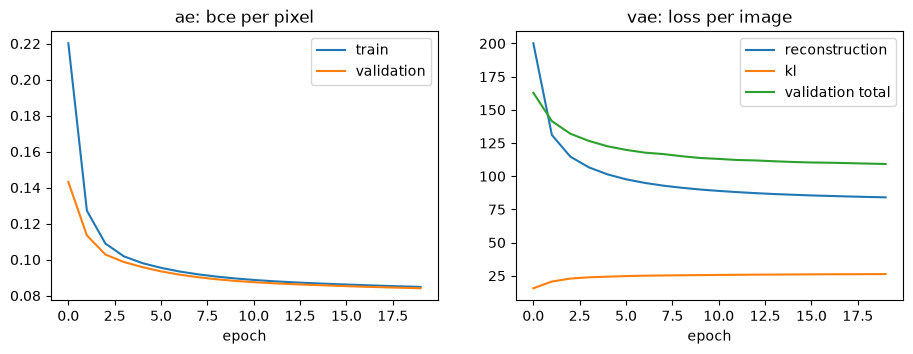

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(ae_history.history["loss"], label="train")
ax[0].plot(ae_history.history["val_loss"], label="validation")
ax[0].set_title("ae: bce per pixel")
ax[1].plot(vae_history.history["rec_loss"], label="reconstruction")
ax[1].plot(vae_history.history["kl_loss"], label="kl")
ax[1].plot(vae_history.history["val_loss"], label="validation total")
ax[1].set_title("vae: loss per image")
for a in ax:
    a.set_xlabel("epoch"); a.legend()
plt.show()

## 4. reconstrucția

pentru vae folosim ca cod media z_mean, fără zgomot. astfel rezultatul este mereu același.

mai jos sunt trei rânduri: imaginile originale, reconstrucțiile ae și reconstrucțiile vae.

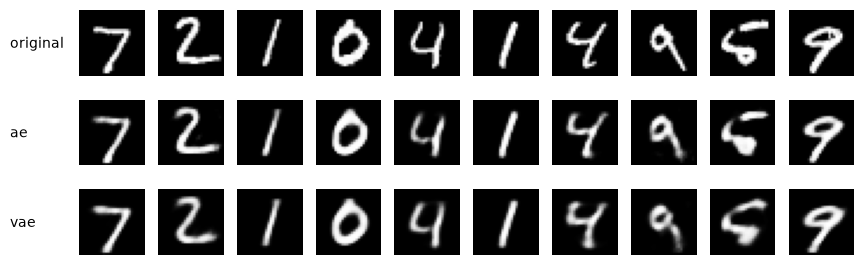

In [15]:
ae_rec = autoencoder.predict(x_test, verbose=0)
vae_rec = vae_decoder.predict(vae_encoder.predict(x_test, verbose=0)[0], verbose=0)

rows = [("original", x_test), ("ae", ae_rec), ("vae", vae_rec)]
plt.figure(figsize=(10, 3.3))
for r, (name, imgs) in enumerate(rows):
    for i in range(10):
        plt.subplot(3, 10, r * 10 + i + 1)
        plt.imshow(imgs[i].reshape(28, 28), cmap="gray"); plt.axis("off")
        if i == 0:
            plt.text(-30, 14, name, va="center")
plt.show()

In [17]:
def bce(a, b):
    b = np.clip(b, 1e-7, 1 - 1e-7)
    return float(np.mean(-(a * np.log(b) + (1 - a) * np.log(1 - b))))

print(f"{'model':<6}{'bce':>10}{'mse':>10}")
for name, rec in [("ae", ae_rec), ("vae", vae_rec)]:
    print(f"{name:<6}{bce(x_test, rec):>10.4f}{np.mean((x_test - rec) ** 2):>10.4f}")

model        bce       mse
ae        0.0841    0.0074
vae       0.0932    0.0101


ae reconstruiește puțin mai precis, pentru că singurul lui scop este reconstrucția. vae trebuie în plus să țină codurile aproape de distribuția normală. de aceea imaginile lui sunt puțin mai încețoșate.

## 5. spațiul latent

luăm codurile imaginilor de test și le reducem la două dimensiuni cu pca. fiecare punct este colorat după cifra lui.

așa vedem cum sunt așezate cifrele în spațiul codurilor.

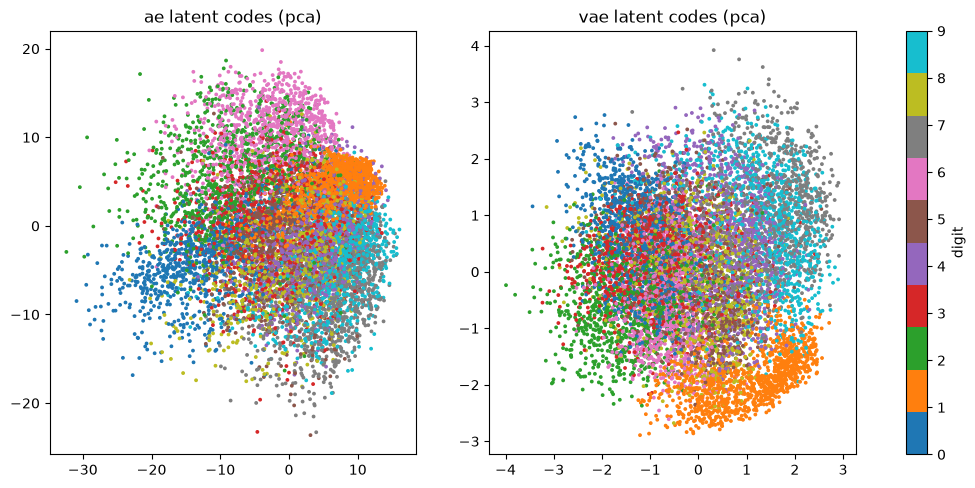

ae: mean -0.66, std 5.53
vae: mean 0.01, std 0.82


In [18]:
ae_codes = ae_encoder.predict(x_test, verbose=0)
vae_codes = vae_encoder.predict(x_test, verbose=0)[0]

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
for a, codes, name in [(ax[0], ae_codes, "ae"), (ax[1], vae_codes, "vae")]:
    c2 = PCA(n_components=2).fit_transform(codes)
    sc = a.scatter(c2[:, 0], c2[:, 1], c=y_test, cmap="tab10", s=3)
    a.set_title(f"{name} latent codes (pca)")
fig.colorbar(sc, ax=ax, label="digit")
plt.show()

for name, codes in [("ae", ae_codes), ("vae", vae_codes)]:
    print(f"{name}: mean {codes.mean():.2f}, std {codes.std():.2f}")

codurile ae nu au un centru sau o scară fixă. codurile vae sunt centrate în 0 și au împrăștierea aproape de 1. asta este exact ce cere termenul kl.

## 6. generarea

facem imagini noi. luăm vectori aleatori din distribuția normală și îi dăm fiecărui decoder.

primele două rânduri sunt de la ae, ultimele două de la vae.

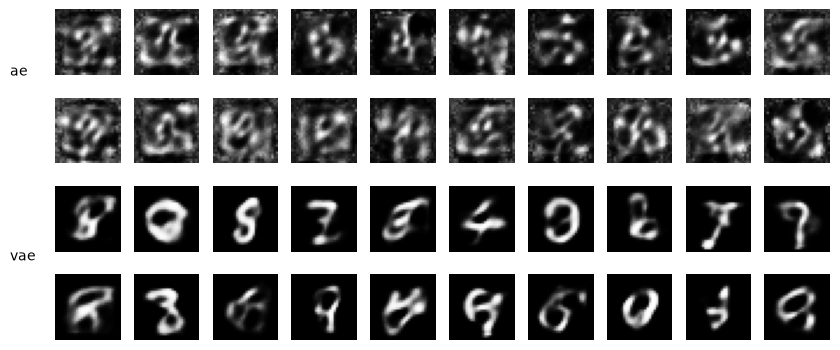

In [19]:
z_rand = np.random.normal(size=(20, LATENT)).astype("float32")
gen = [("ae", ae_decoder.predict(z_rand, verbose=0)),
       ("vae", vae_decoder.predict(z_rand, verbose=0))]

plt.figure(figsize=(10, 4.4))
for r, (name, imgs) in enumerate(gen):
    for i in range(20):
        plt.subplot(4, 10, r * 20 + i + 1)
        plt.imshow(imgs[i].reshape(28, 28), cmap="gray"); plt.axis("off")
    plt.figtext(0.08, 0.72 - r * 0.42, name)
plt.show()

decoderul vae face cifre care se pot citi, chiar dacă primește zgomot aleator. decoderul ae face mai ales pete. motivul este că punctele aleatoare cad în zone din spațiul lui latent unde nu a ajuns nicio imagine de antrenare.

## 7. evaluarea calității generării și interpretarea rezultatelor

antrenarea. pierderea a scăzut la ambele modele. pierderea pe validare este aproape de cea pe antrenare. deci modelele nu învață pe de rost.

reconstrucția. ae are erori mai mici: bce 0.083 și mse 0.007. vae are bce 0.094 și mse 0.010. diferența este mică, iar cifrele se recunosc bine la ambele modele.

spațiul latent. la vae codurile au media 0.01 și împrăștierea 0.82. la ae împrăștierea este 5.81. deci doar codurile vae sunt apropiate de distribuția normală.

generarea. din vectori aleatori vae face cifre clare. ae face mai ales forme fără sens.

concluzia experimentului: ae este mai bun la reconstrucție, iar vae este mai bun la generare.

## 8. concluzii

* ambele modele comprimă 784 de pixeli în 32 de numere și refac cifrele bine.
* ae are o eroare de reconstrucție mai mică, dar spațiul lui latent nu este ordonat și nu putem genera din el.
* vae pierde puțin din claritate, dar spațiul lui latent este continuu și centrat în 0.
* de aceea vae poate genera cifre noi din vectori aleatori, iar ae nu poate.
* ae este potrivit pentru comprimare și extragerea trăsăturilor, iar vae pentru generare.